In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read outputs

In [51]:
def read_output(filename):
    with open(filename, "r") as f:
        out = f.readlines()
    out = [e.strip() for e in out if e.startswith("Iter")]
    out_dict = [{e.strip().split()[0]: float(e.strip().split()[1]) for e in line.split(",")} for line in out]
    df = pd.DataFrame(out_dict)

    # add the trails (should be 10)
    curr_trial = -1
    for i in range(len(df)):
        if df.loc[i, "Iter"] == 0:
            curr_trial += 1
        df.loc[i, "trial"] = curr_trial
    df["trial"] = df["trial"].astype(int)
    return df

In [52]:
natsr_df = read_output("synthetic_output_runs/output_regime_natsr.txt")
ogd_df = read_output("synthetic_output_runs/output_regime_ogd.txt")
er_df = read_output("synthetic_output_runs/output_regime_er.txt")

In [53]:
natsr_df.head()

,Iter,pred_0,pred_1,true,scale,tau,mse,mae,orig_grad_norm,reg_grad_norm,trial
0,0.0,0.044199,-0.091968,0.084868,0.9901,0.9405,0.0068,0.0751,2.1524,0.1430,0
1,1.0,0.080861,-0.053071,-0.201565,0.9806,0.9405,0.0783,0.2799,7.8566,0.1787,0
2,2.0,0.018400,-0.156902,-0.330369,0.9717,0.9405,0.1984,0.4367,13.5350,0.2966,0
3,3.0,-0.005320,-0.207233,-0.681542,0.9639,0.9405,0.5161,0.7173,22.4387,0.5117,0
4,4.0,-0.090945,-0.354594,-0.965511,0.9571,0.9405,0.7238,0.8505,27.6628,0.7733,0


In [54]:
natsr_df.tail()

,Iter,pred_0,pred_1,true,scale,tau,mse,mae,orig_grad_norm,reg_grad_norm,trial
10605,1056.0,-10.834950,-10.685847,-10.731519,0.8078,0.9405,0.0114,0.1069,5.8346,0.8116,9
10606,1057.0,-10.516378,-10.364246,-10.575413,0.8048,0.9405,0.0088,0.0887,19.6525,0.4848,9
10607,1058.0,-10.344209,-10.179947,-10.482652,0.8009,0.9405,0.0162,0.1268,22.0877,0.2753,9
10608,1059.0,-10.295147,-10.106797,-10.295100,0.7963,0.9405,0.0007,0.0185,10.7595,0.2517,9
10609,1060.0,-10.214141,-10.009706,-10.143651,0.7926,0.9405,0.0541,0.1959,18.7242,0.3177,9


# Plots

Trial: 0


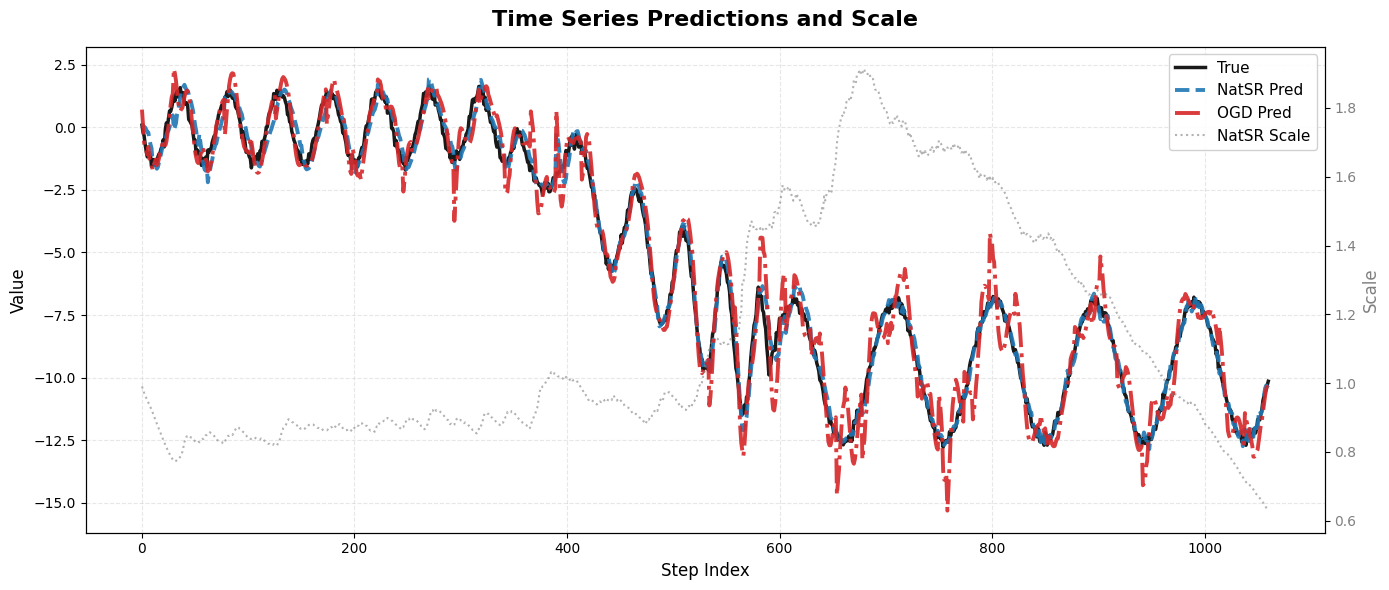

Trial: 1


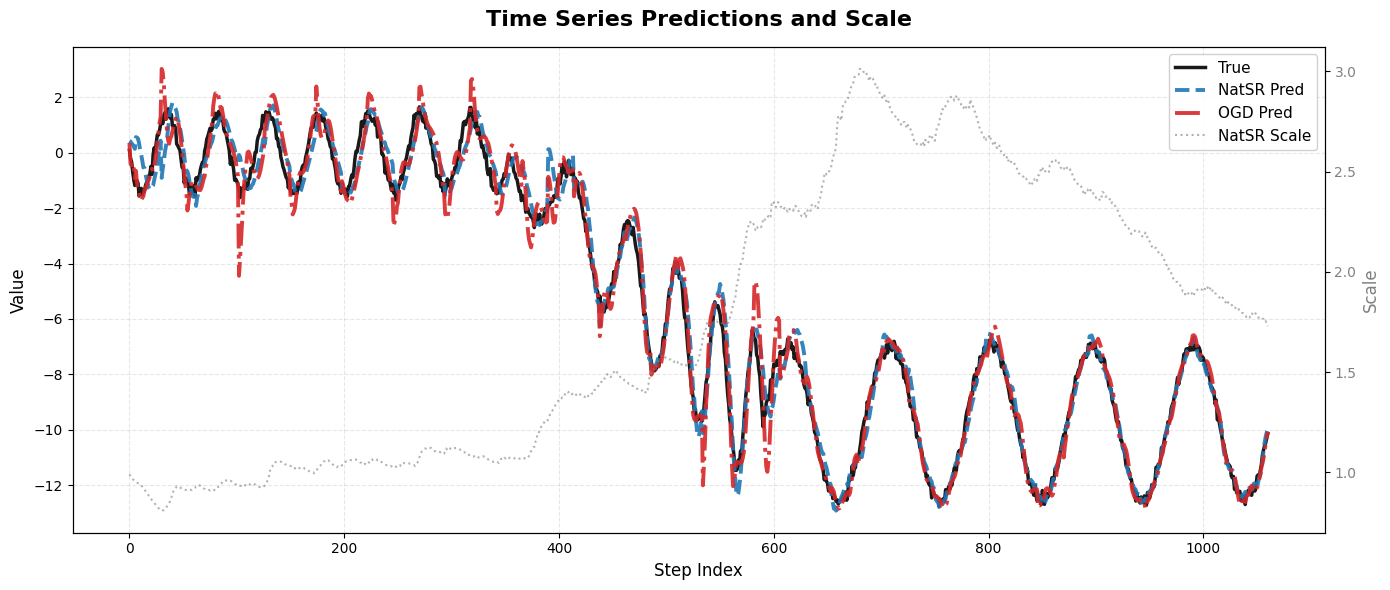

Trial: 2


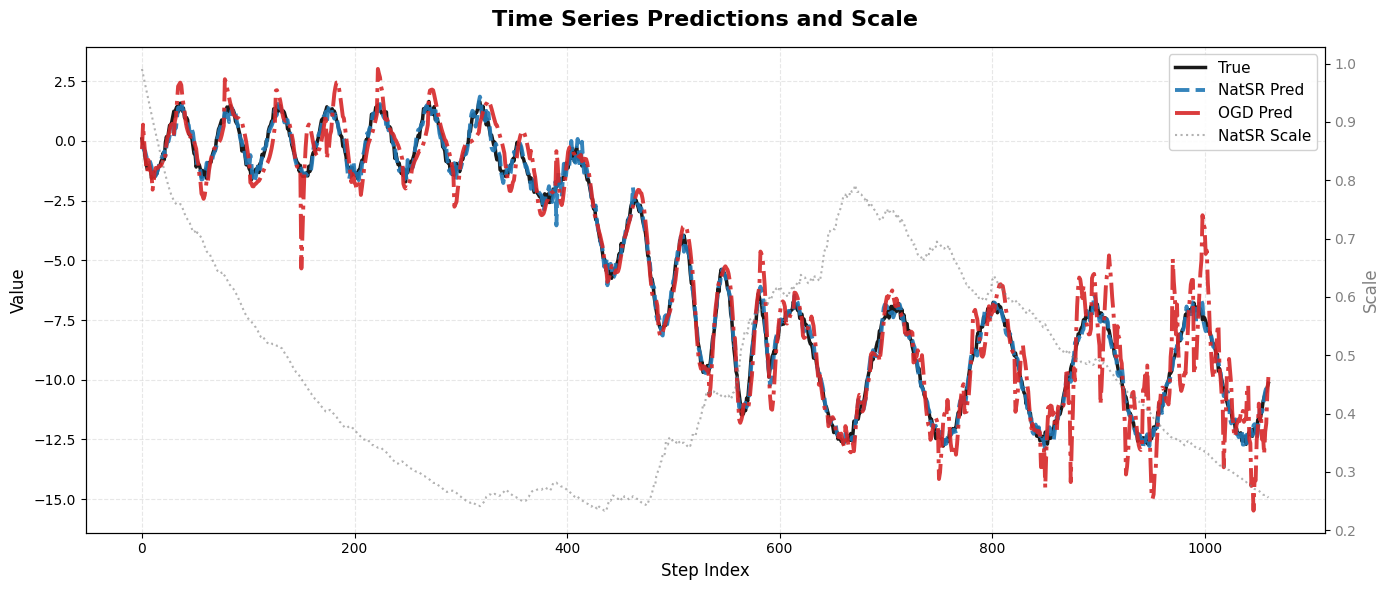

Trial: 3


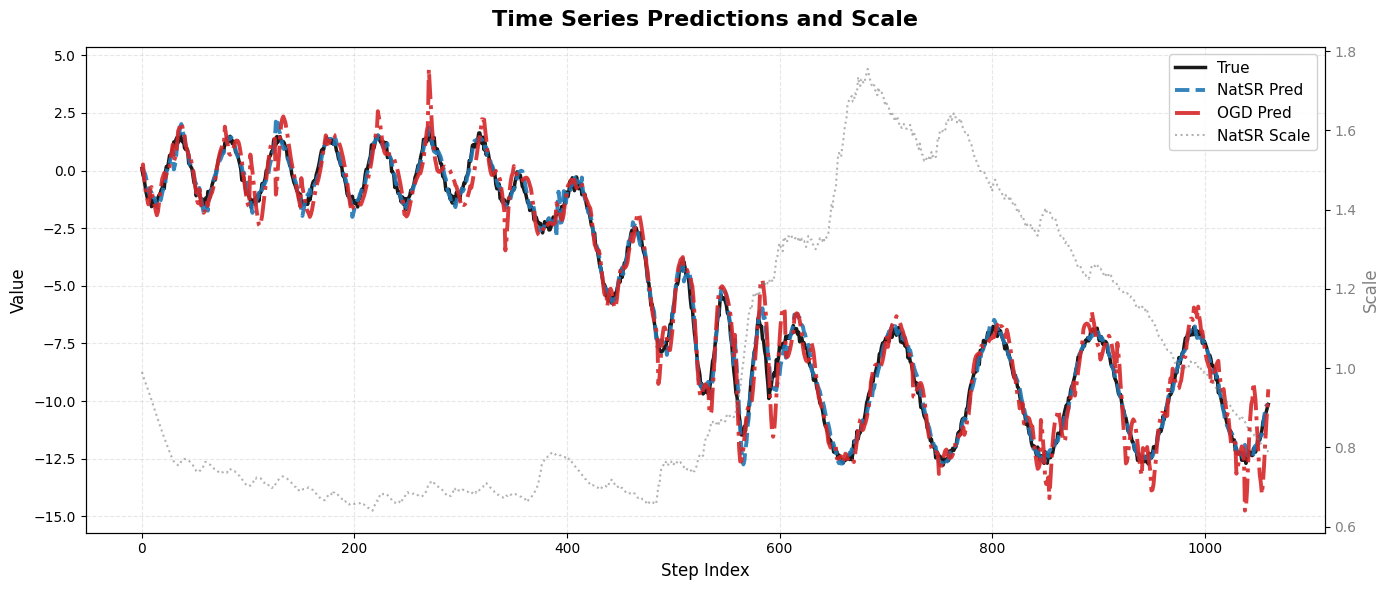

Trial: 4


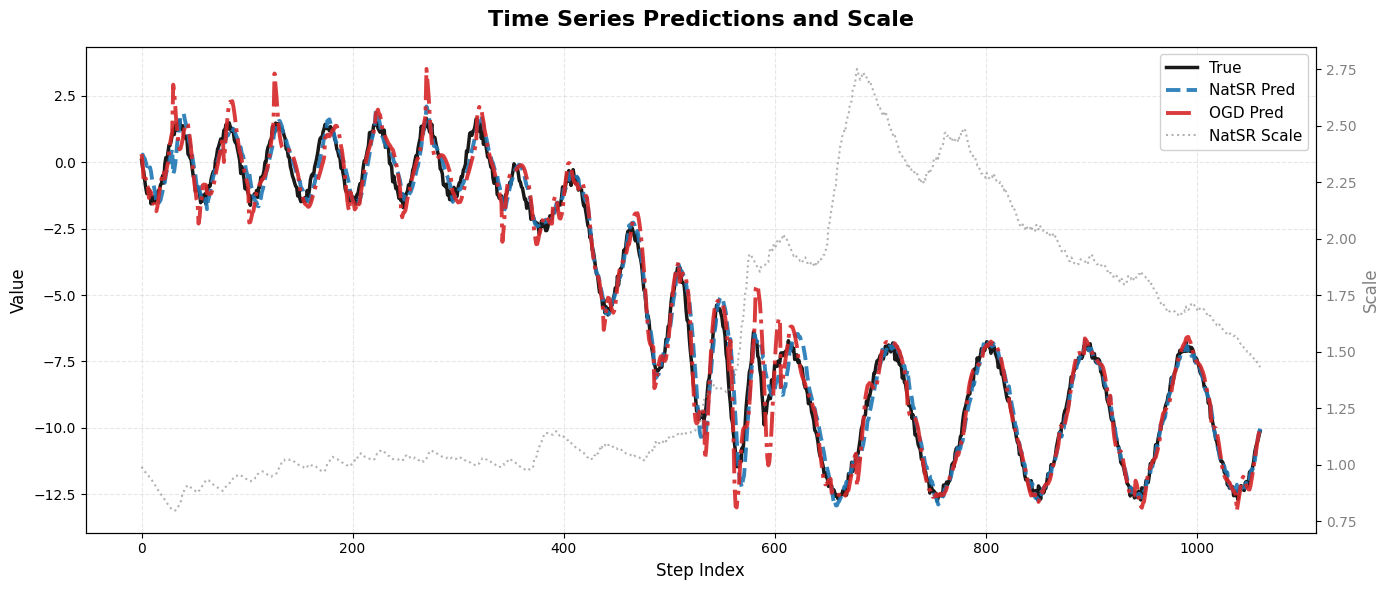

Trial: 5


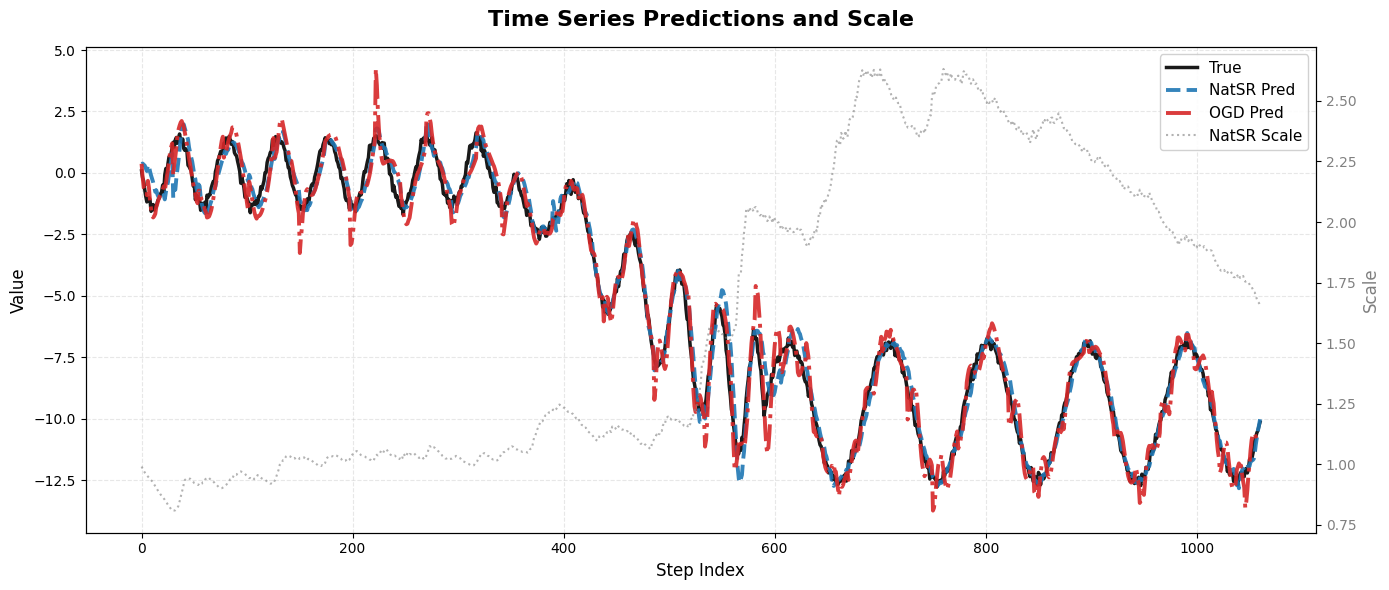

Trial: 6


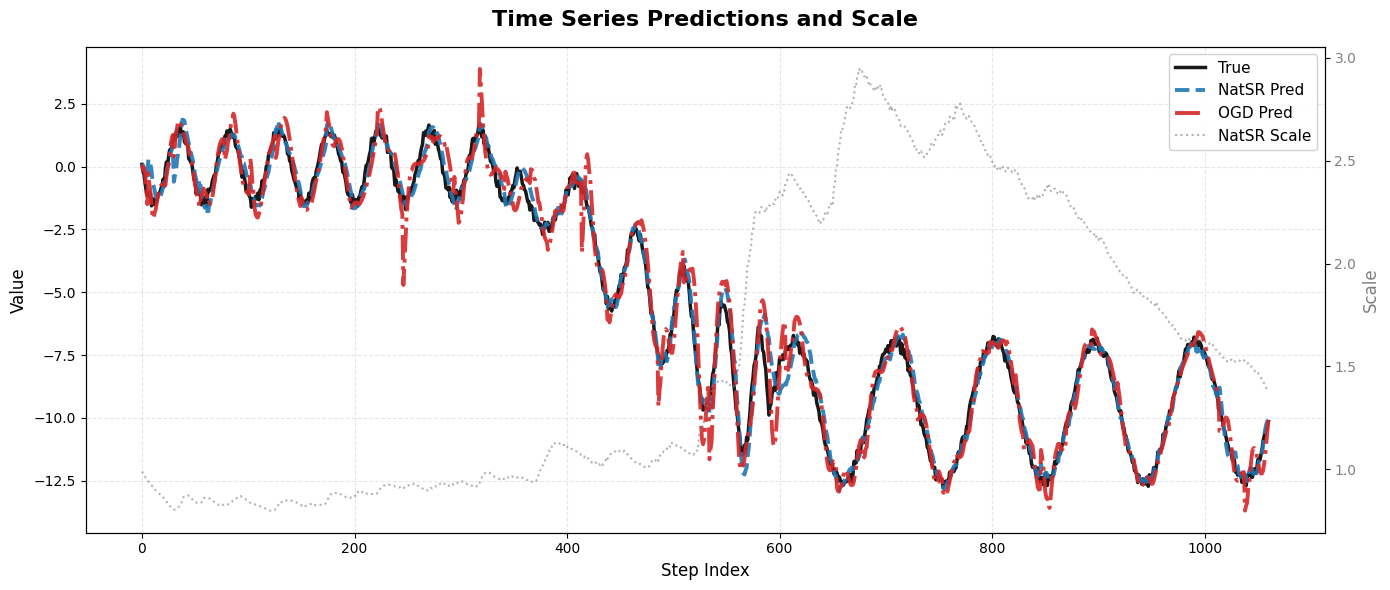

Trial: 7


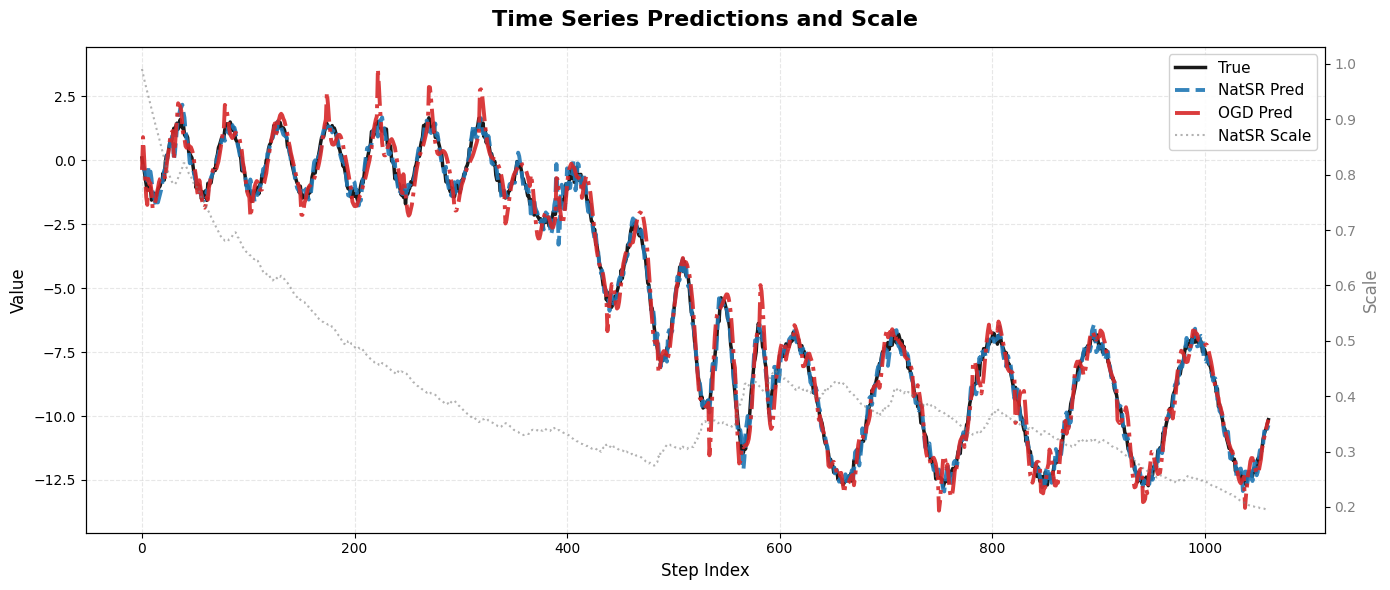

Trial: 8


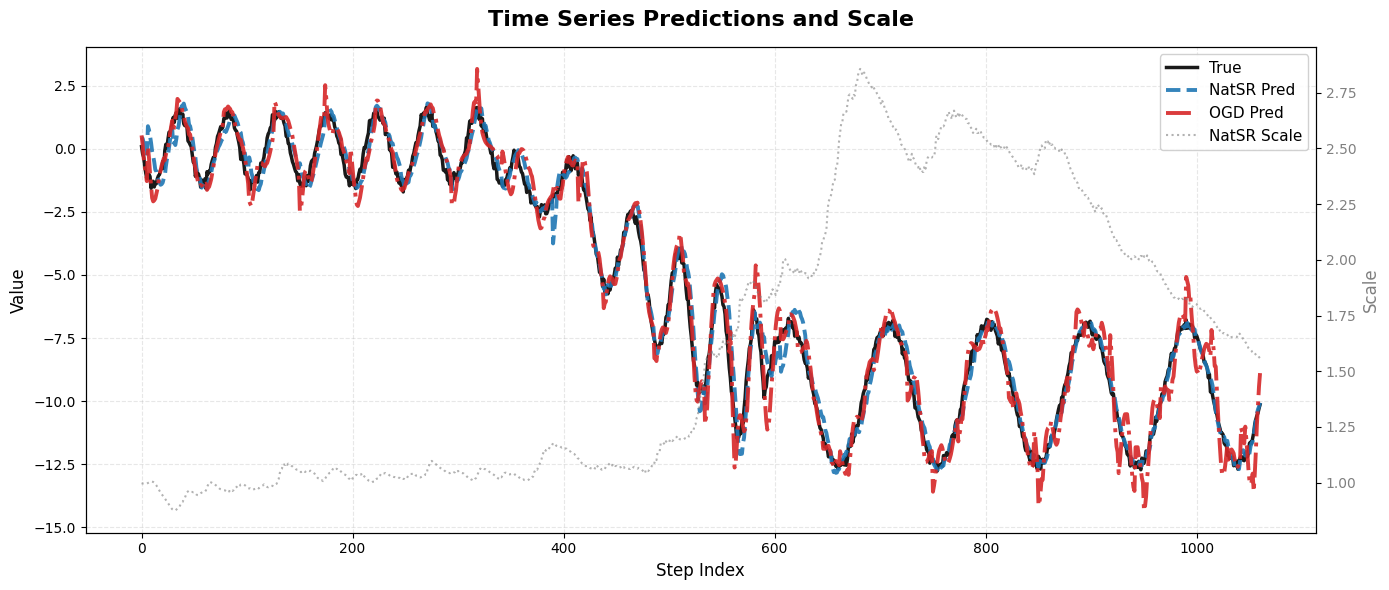

Trial: 9


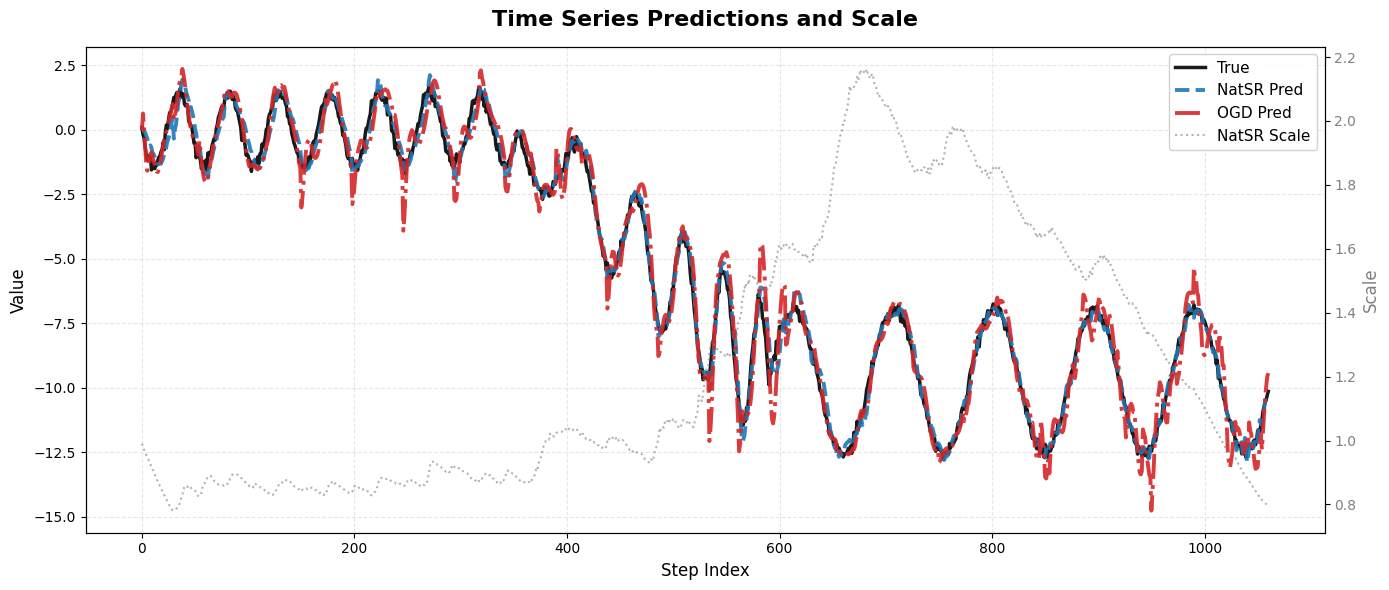

In [55]:
for trial in natsr_df["trial"].unique():
    print(f"Trial: {trial}")
    natsr_df_trial = natsr_df[natsr_df["trial"] == trial]
    ogd_df_trial = ogd_df[ogd_df["trial"] == trial]

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = range(len(natsr_df_trial))

    # --- Left Y-axis: true + predictions ---
    ax1.plot(
        x, natsr_df_trial['true'], 
        label='True', 
        color='black', 
        linestyle='-', 
        linewidth=2.5, 
        alpha=0.9, 
        zorder=3
    )
    ax1.plot(
        x, natsr_df_trial['pred_0'], 
        label='NatSR Pred', 
        color='#1f77b4',   # bright blue
        linestyle='--', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )
    ax1.plot(
        x, ogd_df_trial['pred_0'], 
        label='OGD Pred', 
        color='#d62728',   # vivid red
        linestyle='-.', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )

    ax1.set_xlabel('Step Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.tick_params(axis='both')
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=1)

    # --- Right Y-axis: scale (make subtle) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, natsr_df_trial['scale'], 
        label='NatSR Scale', 
        color='gray', 
        linestyle=':', 
        linewidth=1.5, 
        alpha=0.6, 
        zorder=2
    )
    ax2.set_ylabel('Scale', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # --- Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines_1 + lines_2, labels_1 + labels_2, 
        loc='upper right', 
        fontsize=11, 
        frameon=True, 
        fancybox=True, 
        framealpha=0.9
    )

    # --- Title ---
    plt.title('Time Series Predictions and Scale', fontsize=16, weight='bold', pad=15)

    plt.tight_layout()
    plt.show()


Trial: 0


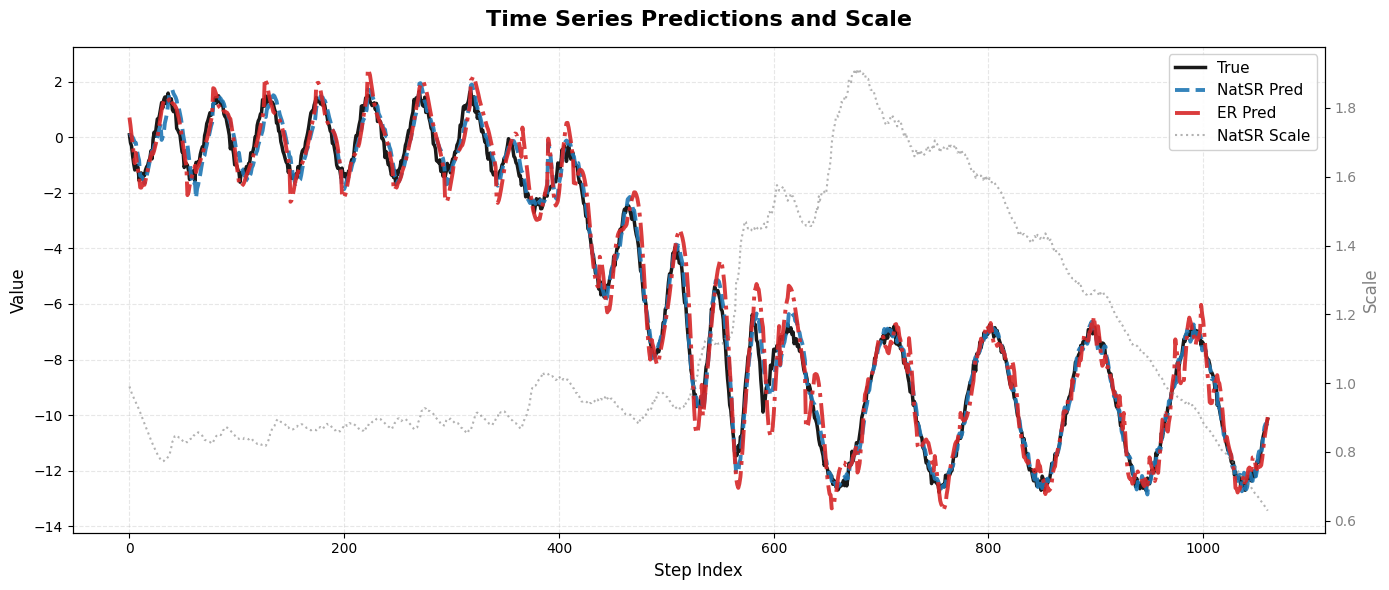

Trial: 1


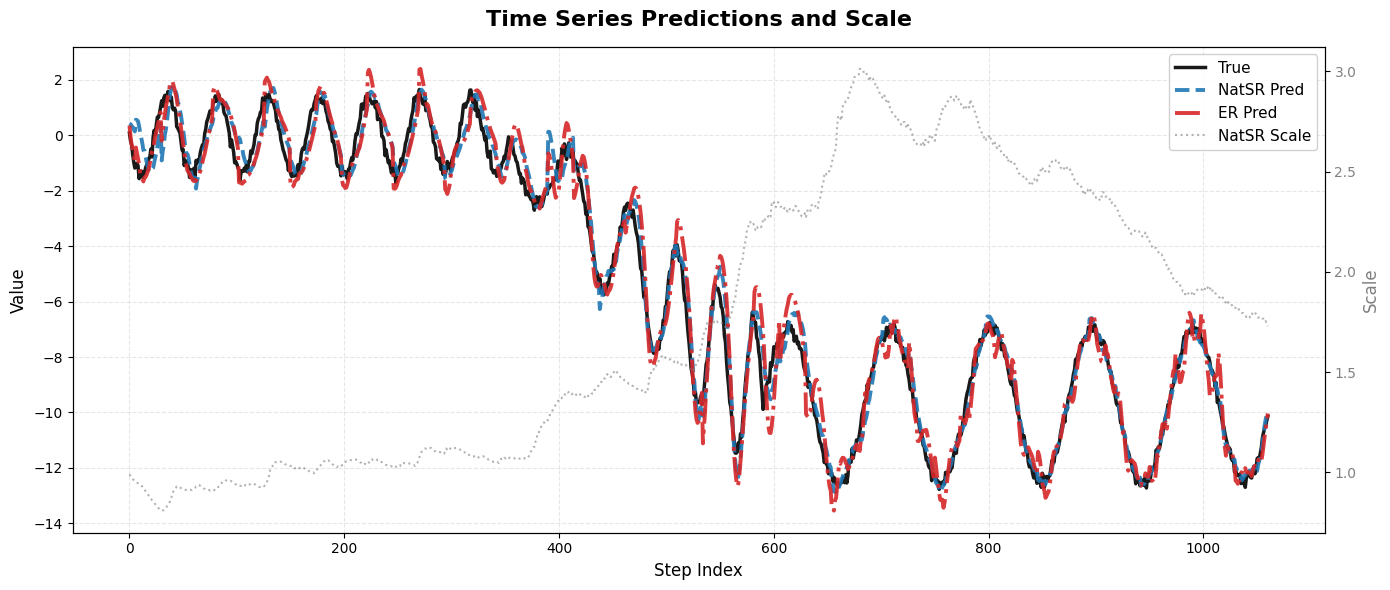

Trial: 2


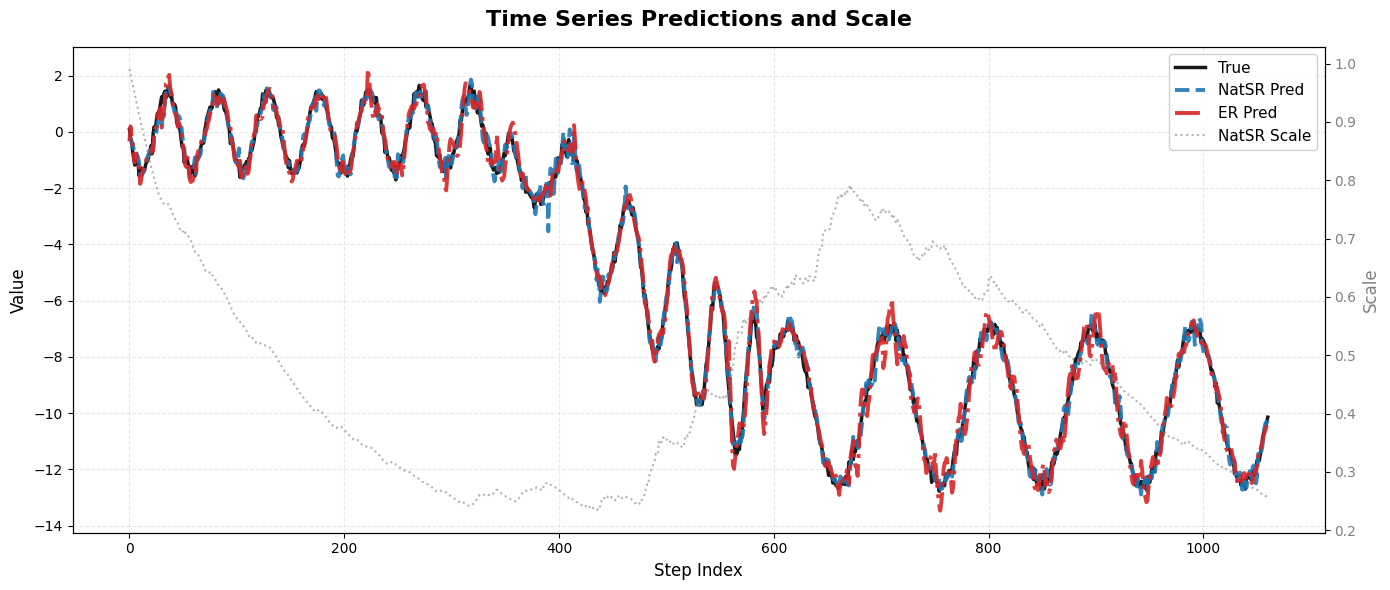

Trial: 3


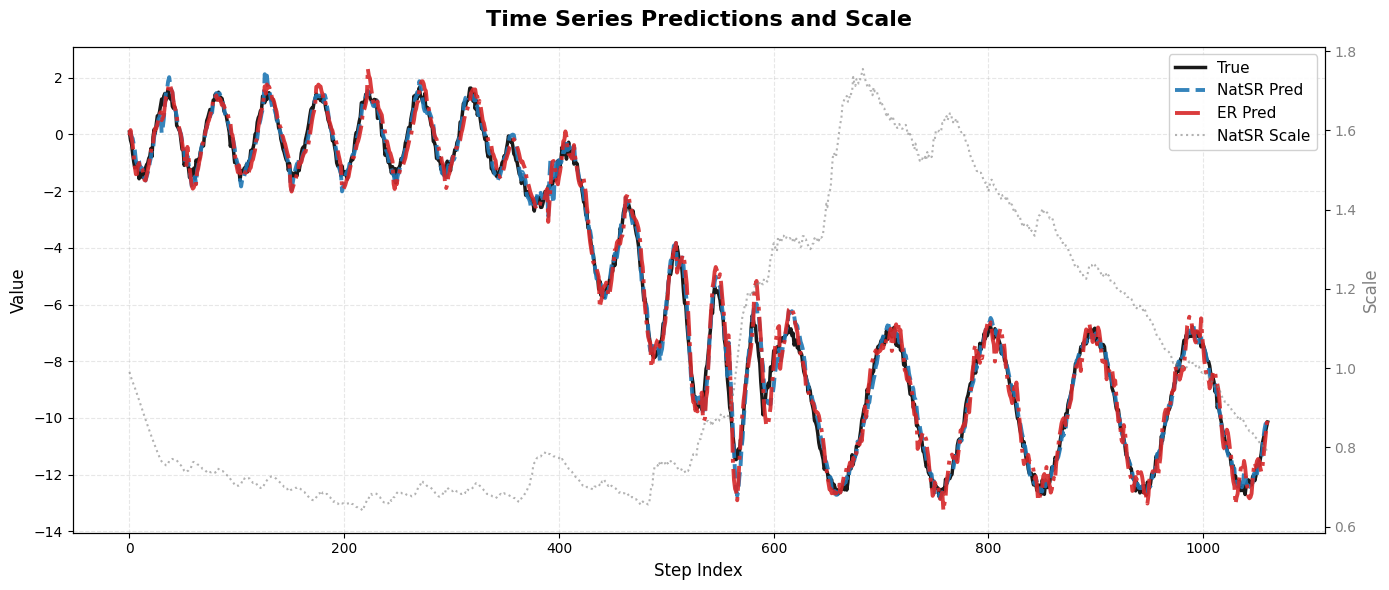

Trial: 4


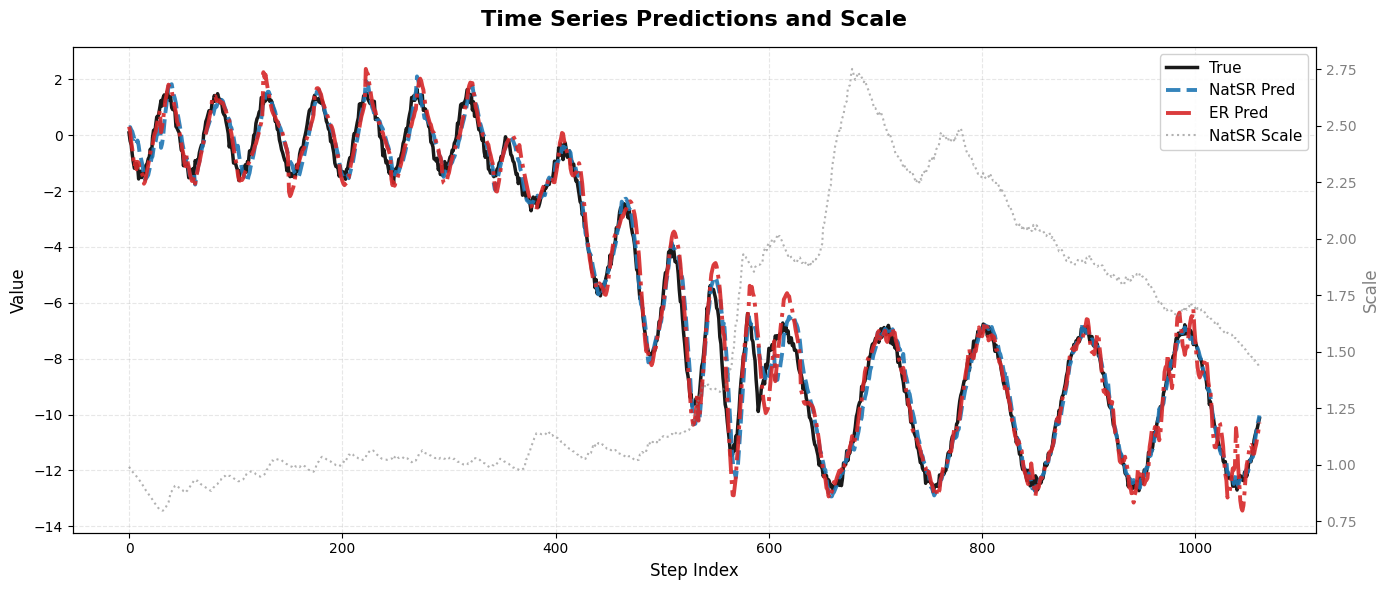

Trial: 5


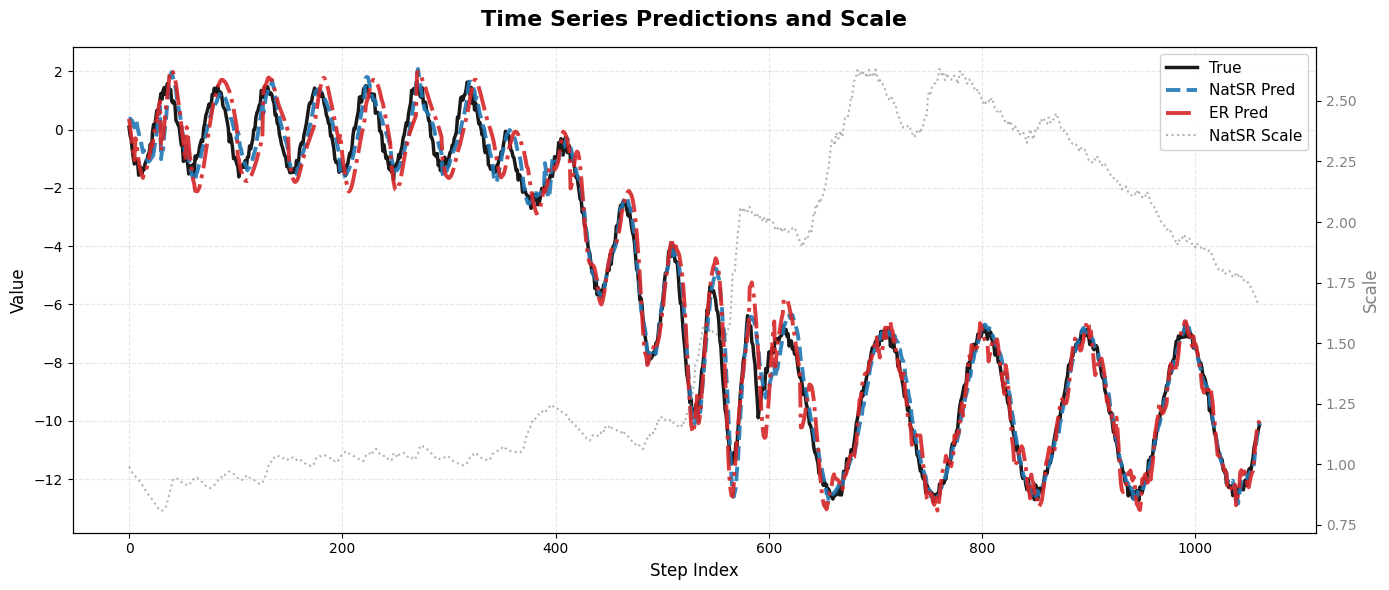

Trial: 6


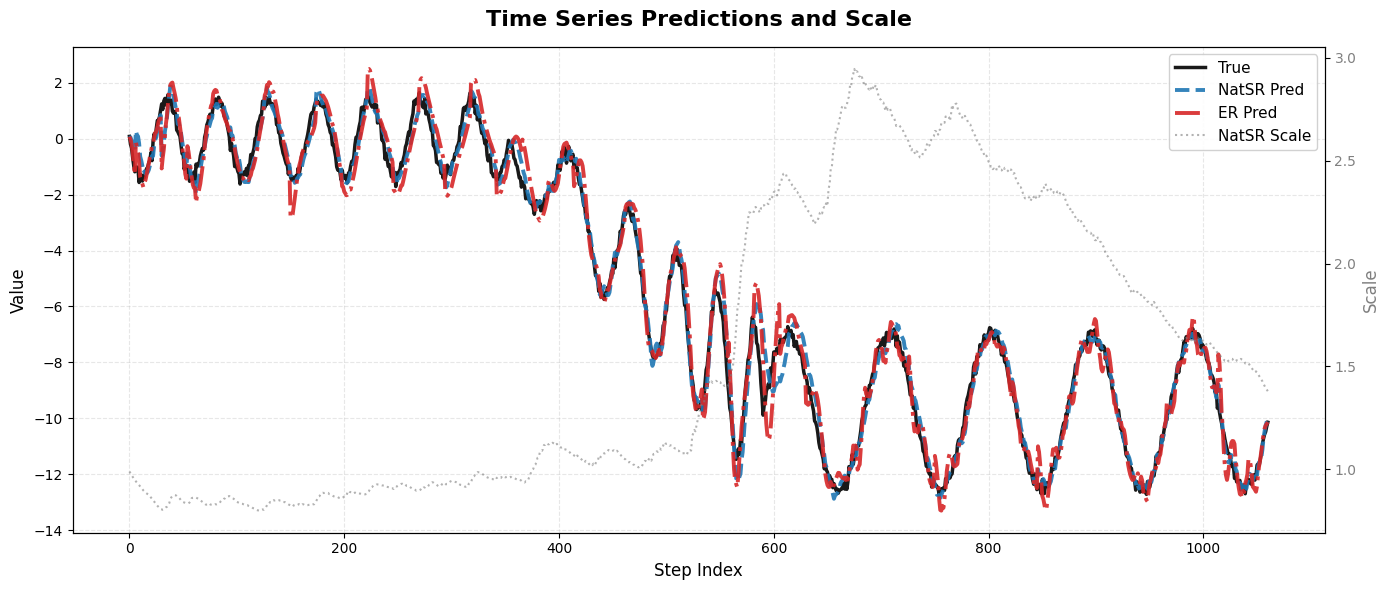

Trial: 7


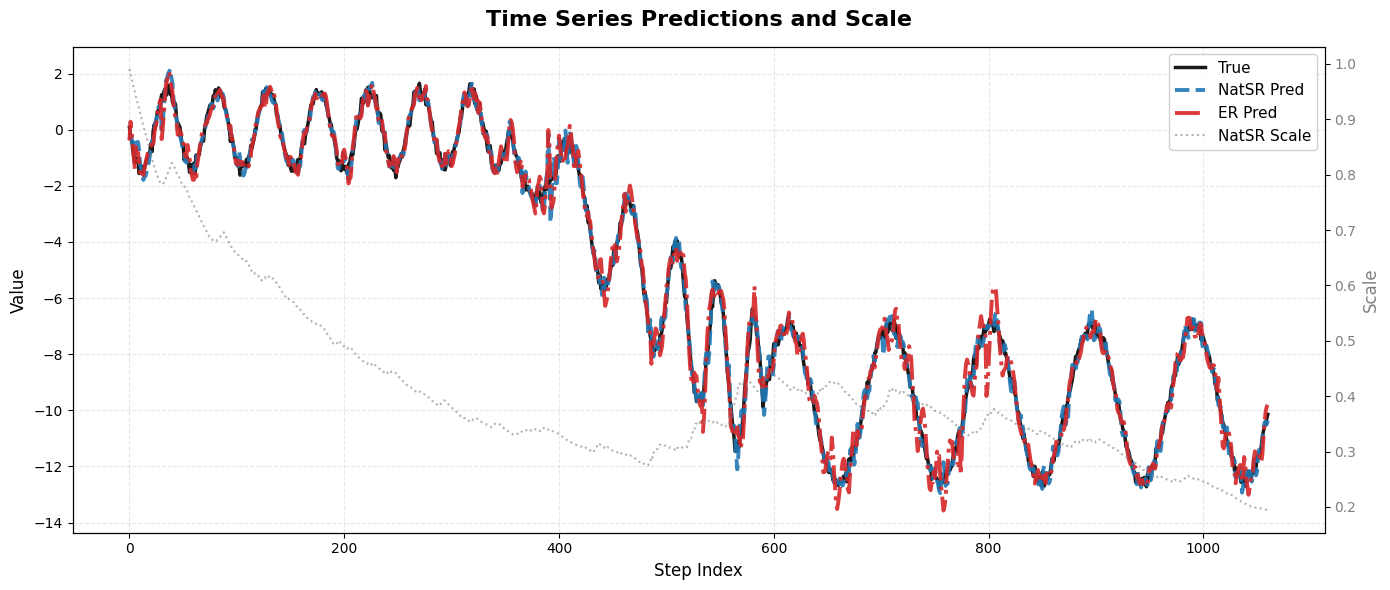

Trial: 8


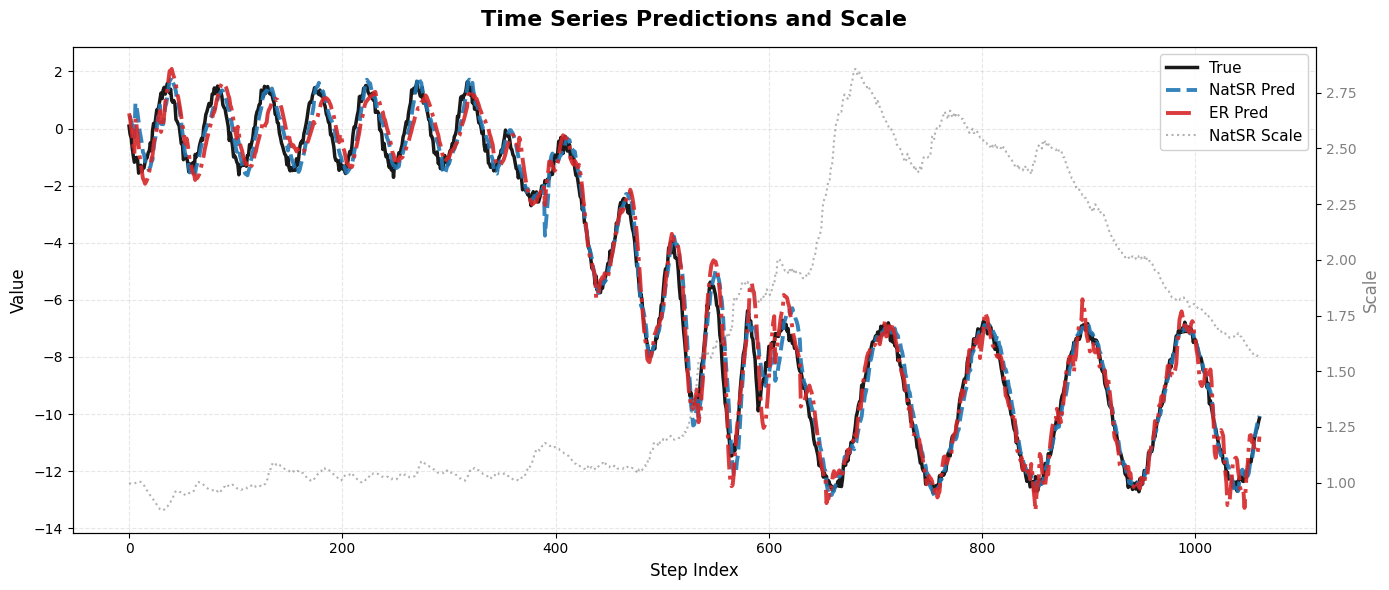

Trial: 9


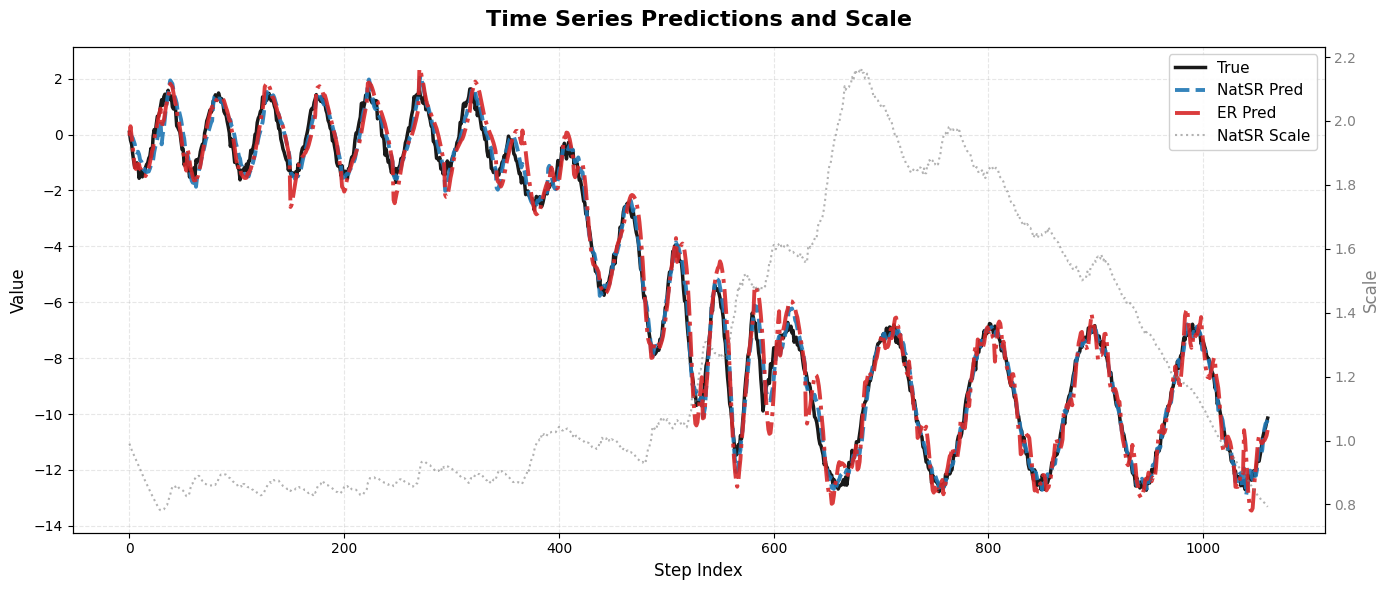

In [56]:
for trial in natsr_df["trial"].unique():
    print(f"Trial: {trial}")
    natsr_df_trial = natsr_df[natsr_df["trial"] == trial]
    ogd_df_trial = ogd_df[ogd_df["trial"] == trial]
    er_df_trial = er_df[er_df["trial"] == trial]

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = range(len(natsr_df_trial))

    # --- Left Y-axis: true + predictions ---
    ax1.plot(
        x, natsr_df_trial['true'], 
        label='True', 
        color='black', 
        linestyle='-', 
        linewidth=2.5, 
        alpha=0.9, 
        zorder=3
    )
    ax1.plot(
        x, natsr_df_trial['pred_0'], 
        label='NatSR Pred', 
        color='#1f77b4',   # bright blue
        linestyle='--', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )
    ax1.plot(
        x, er_df_trial['pred_0'], 
        label='ER Pred', 
        color='#d62728',   # vivid red
        linestyle='-.', 
        linewidth=2.8, 
        alpha=0.9, 
        zorder=4
    )

    ax1.set_xlabel('Step Index', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.tick_params(axis='both')
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=1)

    # --- Right Y-axis: scale (make subtle) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x, natsr_df_trial['scale'], 
        label='NatSR Scale', 
        color='gray', 
        linestyle=':', 
        linewidth=1.5, 
        alpha=0.6, 
        zorder=2
    )
    ax2.set_ylabel('Scale', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # --- Legend ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines_1 + lines_2, labels_1 + labels_2, 
        loc='upper right', 
        fontsize=11, 
        frameon=True, 
        fancybox=True, 
        framealpha=0.9
    )

    # --- Title ---
    plt.title('Time Series Predictions and Scale', fontsize=16, weight='bold', pad=15)

    plt.tight_layout()
    plt.show()


# Plot Statistics of different trials

In [57]:
real_ts = ogd_df[ogd_df["trial"] == 0]["true"]
# natsr
mean_pred_natsr = natsr_df.groupby('Iter')['pred_0'].mean()
q1_pred_natsr = natsr_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_natsr = natsr_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_natsr = natsr_df.groupby('Iter')['pred_0'].std()
mean_grad_natsr = natsr_df.groupby('Iter')['reg_grad_norm'].mean()
# ogd
mean_pred_ogd = ogd_df.groupby('Iter')['pred_0'].mean()
q1_pred_ogd = ogd_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_ogd = ogd_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_ogd = ogd_df.groupby('Iter')['pred_0'].std()
mean_grad_ogd = ogd_df.groupby('Iter')['orig_grad_norm'].mean()
# er
mean_pred_er = er_df.groupby('Iter')['pred_0'].mean()
q1_pred_er = er_df.groupby('Iter')['pred_0'].quantile(0.25)
q3_pred_er = er_df.groupby('Iter')['pred_0'].quantile(0.75)
std_pred_er = er_df.groupby('Iter')['pred_0'].std()
mean_grad_er = er_df.groupby('Iter')['orig_grad_norm'].mean()

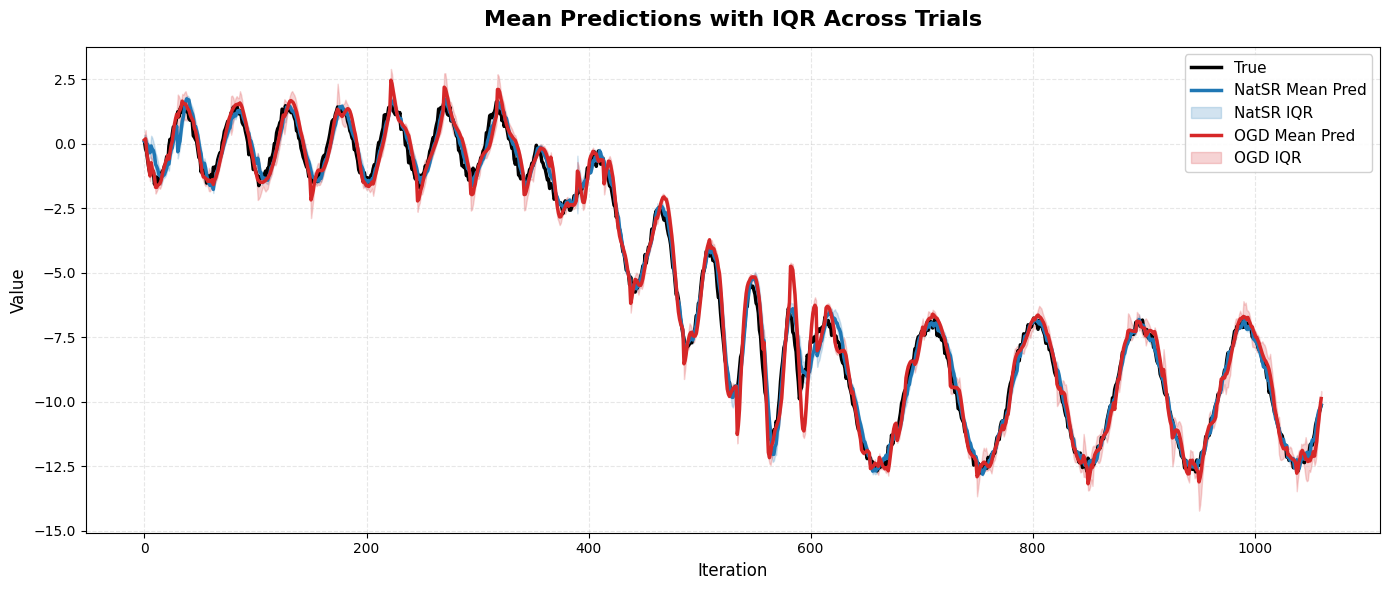

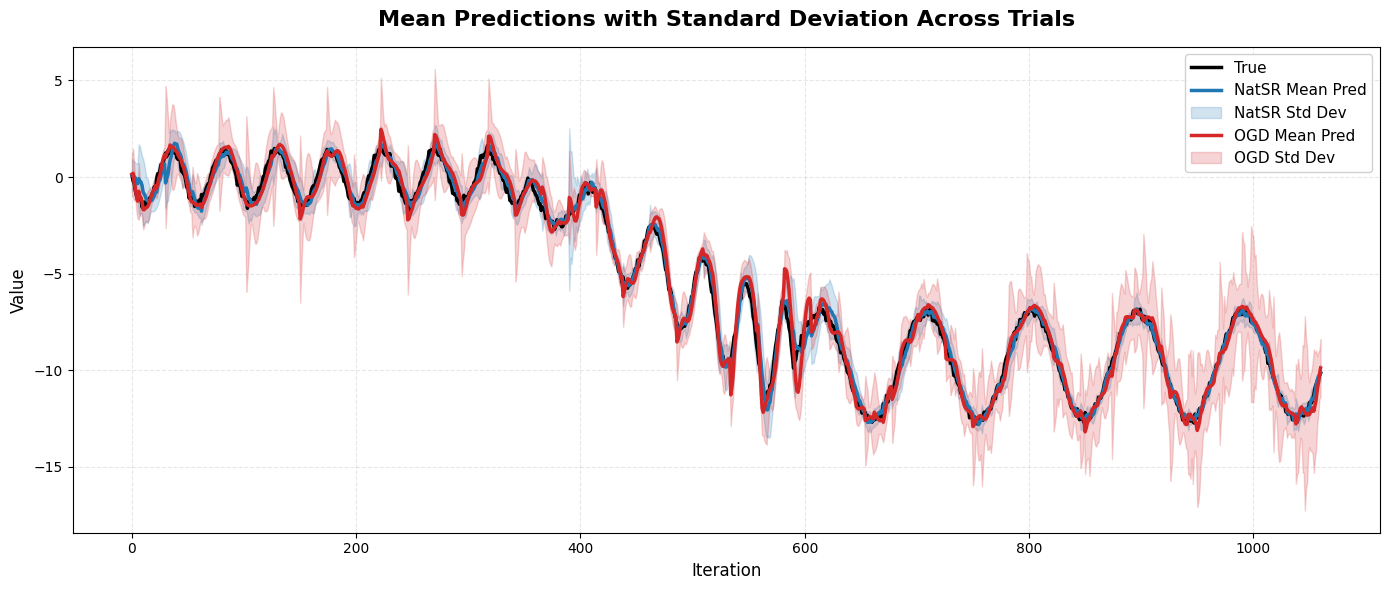

In [58]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=2.5)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, q1_pred_natsr, q3_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR IQR')
plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
plt.fill_between(mean_pred_ogd.index, q1_pred_ogd, q3_pred_ogd, color='#d62728', alpha=0.2, label='OGD IQR')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with IQR Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=2.5)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR Std Dev')
plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
plt.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color='#d62728', alpha=0.2, label='OGD Std Dev')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

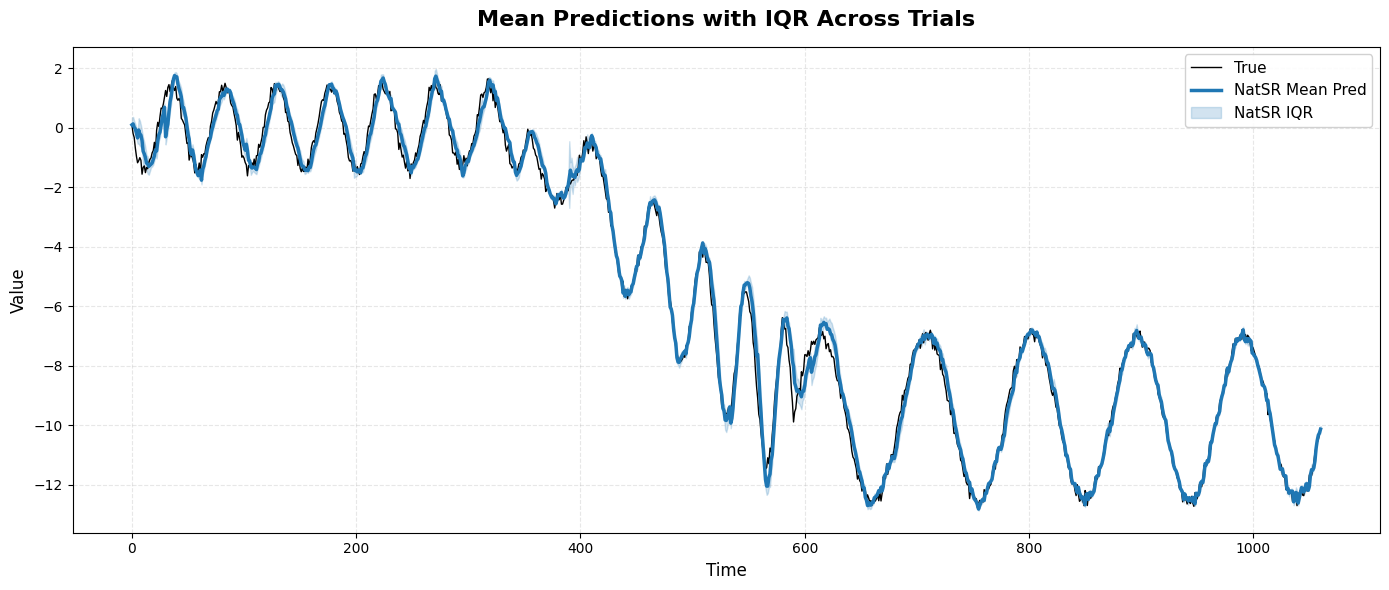

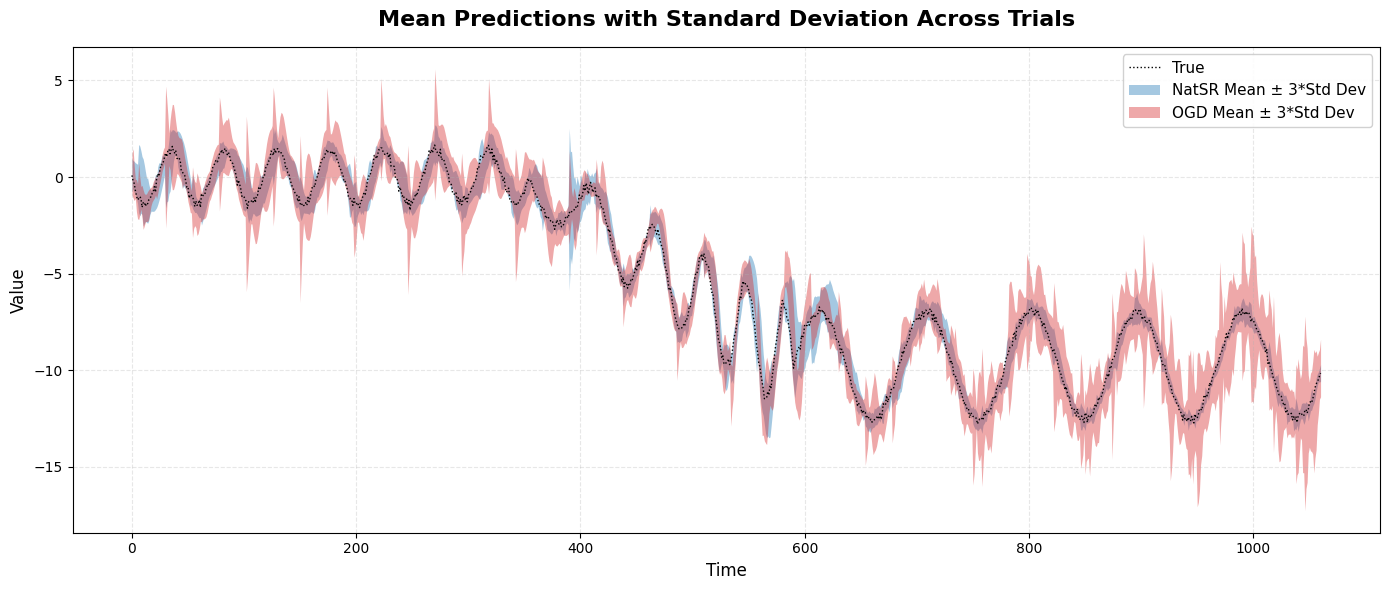

In [59]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=1)
plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=2.5)
plt.fill_between(mean_pred_natsr.index, q1_pred_natsr, q3_pred_natsr, color='#1f77b4', alpha=0.2, label='NatSR IQR')
# plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=2.5)
# plt.fill_between(mean_pred_ogd.index, q1_pred_ogd, q3_pred_ogd, color='#d62728', alpha=0.2, label='OGD IQR')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with IQR Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(real_ts.index, real_ts, label='True', color='black', linewidth=1, linestyle='dotted')
#plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=1)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color='#1f77b4', alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
#plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=1)
plt.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color='#d62728', alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

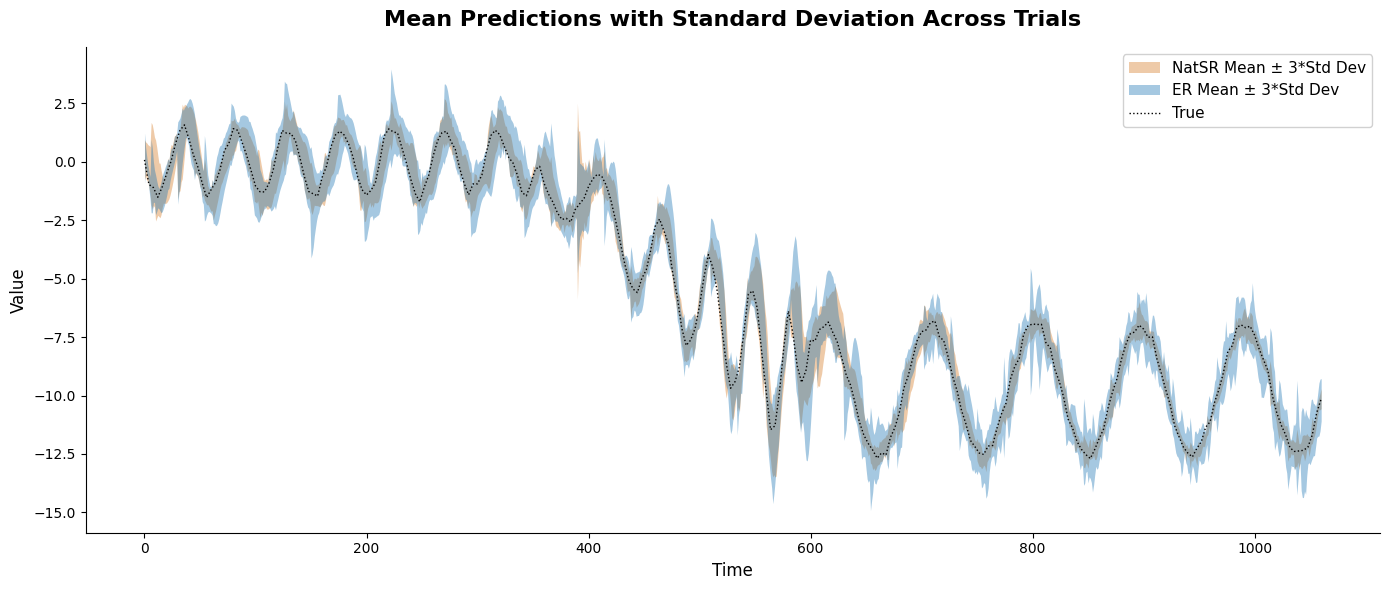

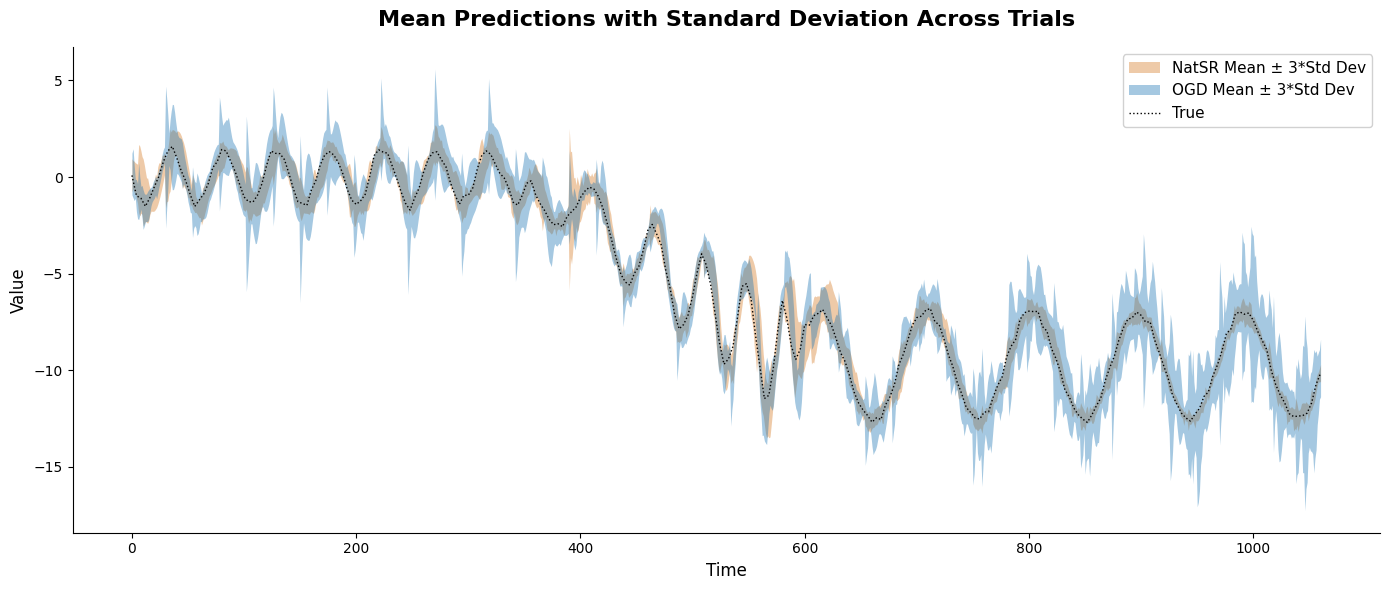

In [60]:
# Plot
plt.figure(figsize=(14, 6))
#plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=1)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color="#d67c27", alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
#plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=1)
plt.fill_between(mean_pred_er.index, mean_pred_er - 3*std_pred_er, mean_pred_er + 3*std_pred_er, color='#1f77b4', alpha=0.4, label='ER Mean ± 3*Std Dev', linewidth=0)
plt.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
#plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

# Plot
plt.figure(figsize=(14, 6))
#plt.plot(mean_pred_natsr.index, mean_pred_natsr, label='NatSR Mean Pred', color='#1f77b4', linewidth=1)
plt.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr, color='#d67c27', alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
#plt.plot(mean_pred_ogd.index, mean_pred_ogd, label='OGD Mean Pred', color='#d62728', linewidth=1)
plt.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd, color='#1f77b4', alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0)
plt.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Mean Predictions with Standard Deviation Across Trials', fontsize=16, weight='bold', pad=15)
plt.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.9)
#plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

# Final Plots

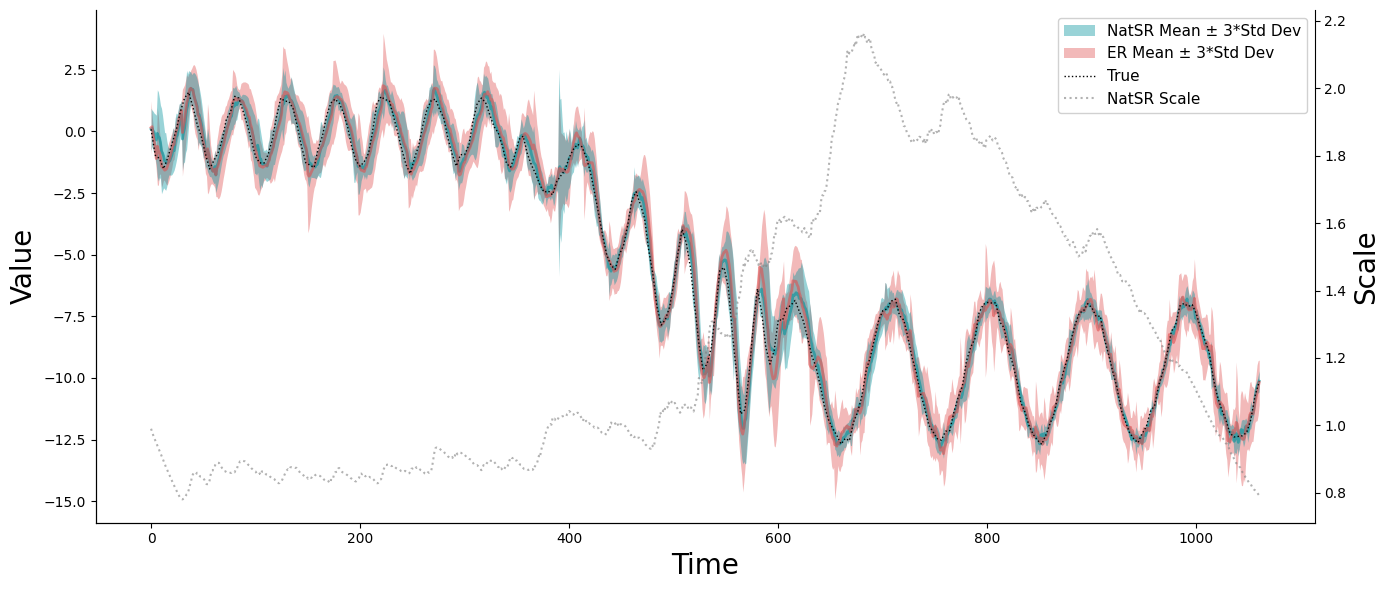

In [61]:
fig, ax1 = plt.subplots(figsize=(14, 6))

mean_alpha = 0.6
natsr_col = '#00929c'
other_col = "#df5151"

ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0, zorder=2)
ax1.plot(mean_pred_er.index, mean_pred_er, color=other_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_er.index, mean_pred_er - 3*std_pred_er, mean_pred_er + 3*std_pred_er,
                 color=other_col, alpha=0.4, label='ER Mean ± 3*Std Dev', linewidth=0, zorder=1)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)
# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)   # <--- THIS removes the vertical bound

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
#plt.savefig("regime_comparison_natsr_ER.png", dpi=300)
plt.show()

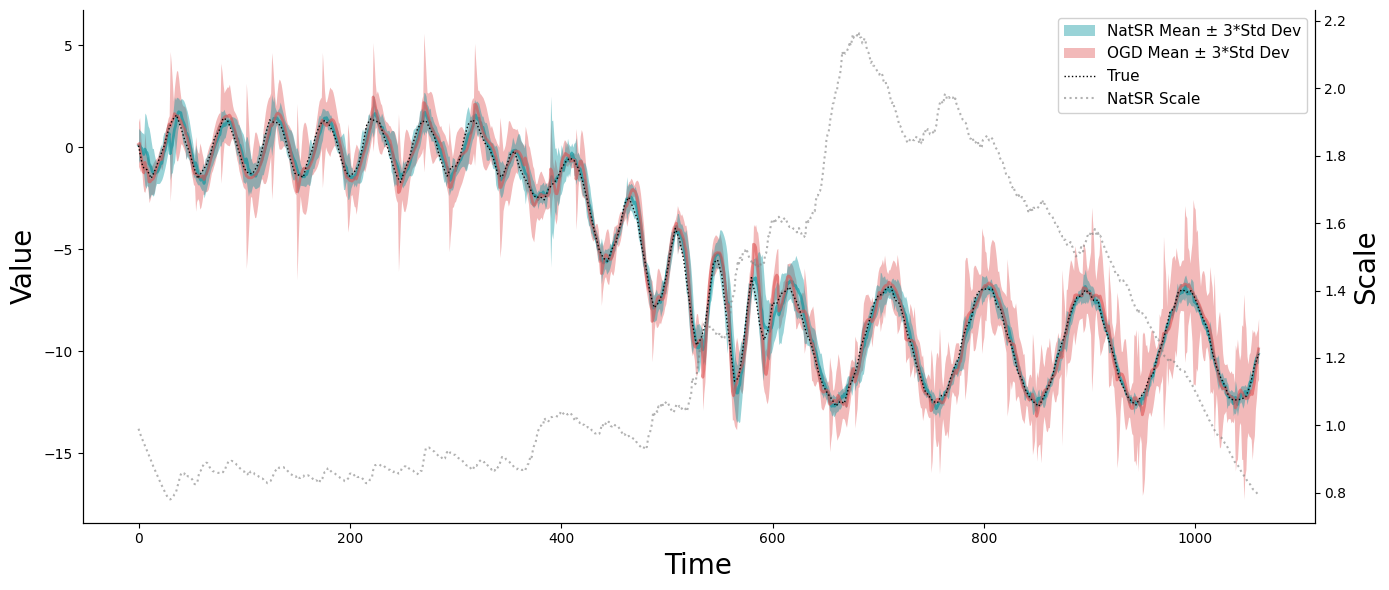

In [62]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0, zorder=2)
ax1.plot(mean_pred_ogd.index, mean_pred_ogd, color=other_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0, zorder=1)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
#plt.savefig("regime_comparison_natsr_OGD.png", dpi=300)
plt.show()

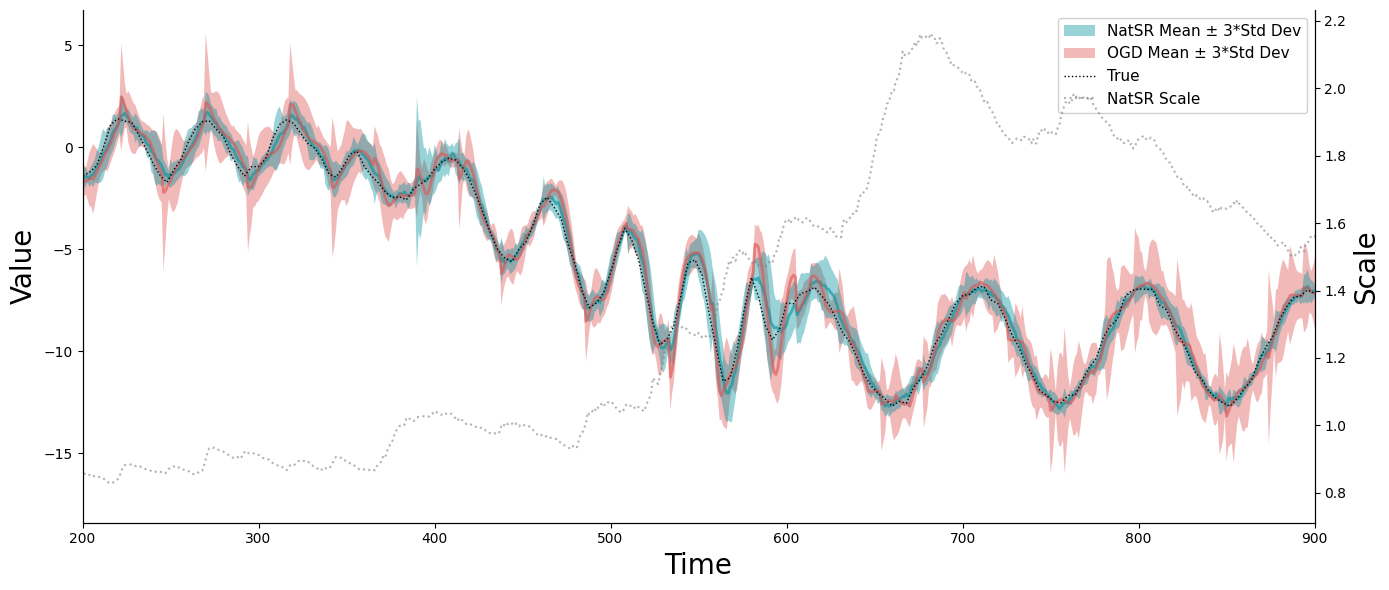

In [63]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0, zorder=2)
ax1.plot(mean_pred_ogd.index, mean_pred_ogd, color=other_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0, zorder=1)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.xlim(200, 900)
plt.tight_layout()
#plt.savefig("regime_comparison_natsr_OGD_zoomed.png", dpi=300)
plt.show()

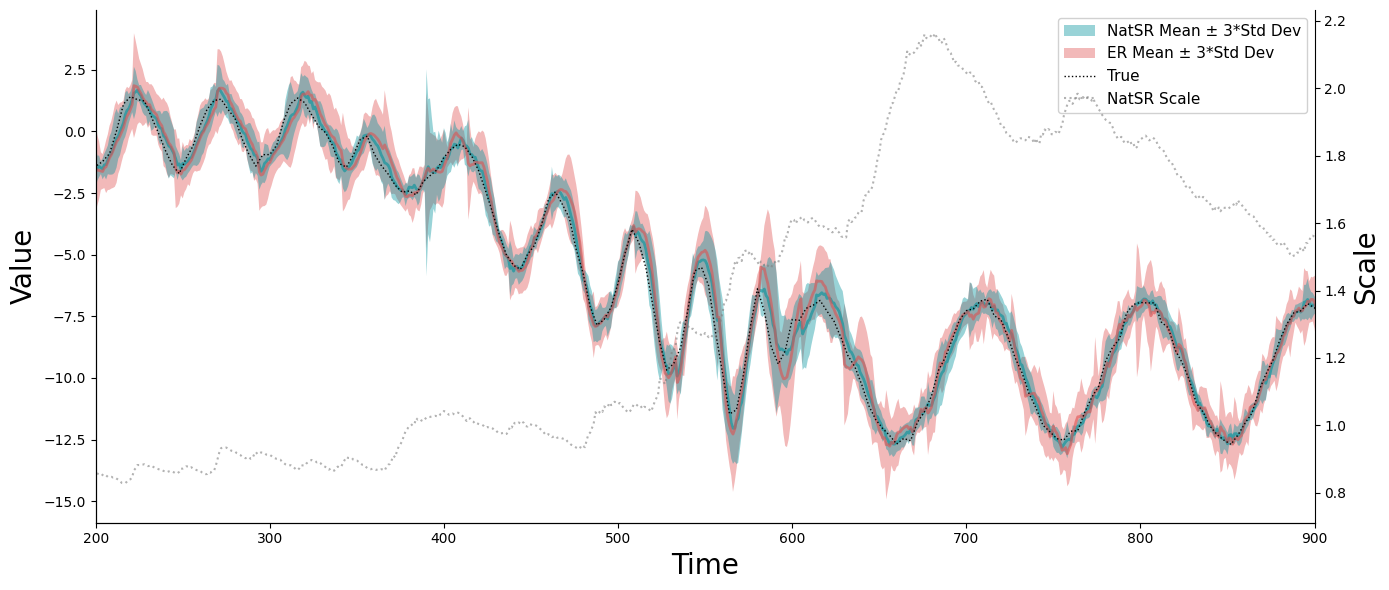

In [64]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0, zorder=2)
ax1.plot(mean_pred_er.index, mean_pred_er, color=other_col, linewidth=2, alpha=mean_alpha)
ax1.fill_between(mean_pred_er.index, mean_pred_er - 3*std_pred_er, mean_pred_er + 3*std_pred_er,
                 color=other_col, alpha=0.4, label='ER Mean ± 3*Std Dev', linewidth=0, zorder=1)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=1, linestyle='dotted')
ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6, zorder=2)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)   # <--- THIS removes the vertical bound

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.xlim(200, 900)
plt.tight_layout()
#plt.savefig("regime_comparison_natsr_ER_zoomed.png", dpi=300)
plt.show()

## v2

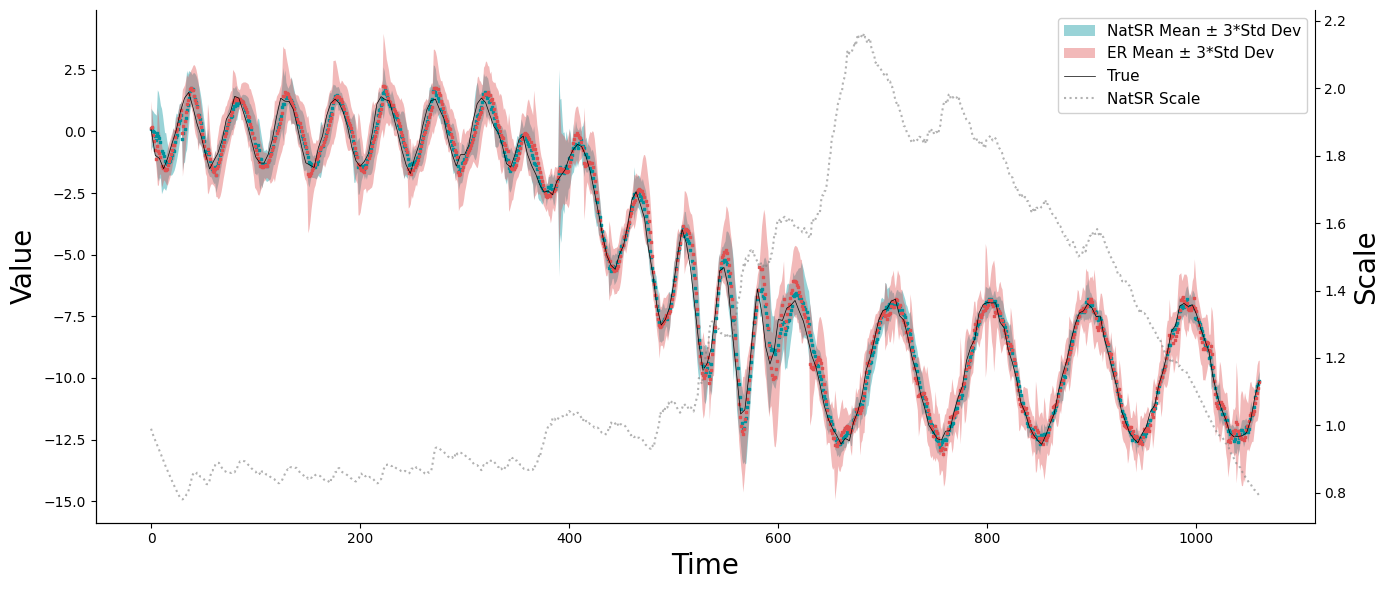

In [65]:
fig, ax1 = plt.subplots(figsize=(14, 6))

mean_alpha = 0.6
natsr_col = '#00929c'
other_col = "#df5151"

ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
ax1.fill_between(mean_pred_er.index, mean_pred_er - 3*std_pred_er, mean_pred_er + 3*std_pred_er,
                 color=other_col, alpha=0.4, label='ER Mean ± 3*Std Dev', linewidth=0)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=0.5)
ax1.scatter(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, s=3, marker='s')
ax1.scatter(mean_pred_er.index, mean_pred_er, color=other_col, s=3, marker='s')

ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)
# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)   # <--- THIS removes the vertical bound

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
#plt.savefig("regime_comparison_natsr_ER_v2.png", dpi=300)
plt.show()

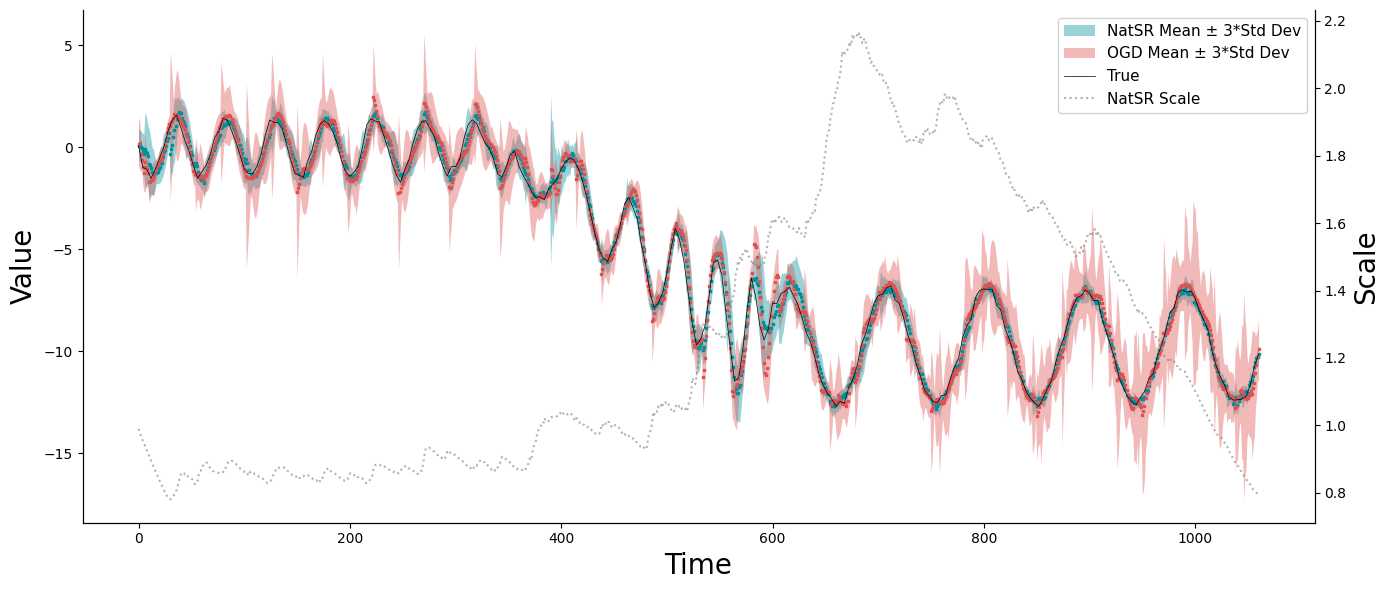

In [66]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=0.5)
ax1.scatter(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, s=3, marker='s')
ax1.scatter(mean_pred_ogd.index, mean_pred_ogd, color=other_col, s=3, marker='s')

ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
#plt.savefig("regime_comparison_natsr_OGD_v2.png", dpi=300)
plt.show()

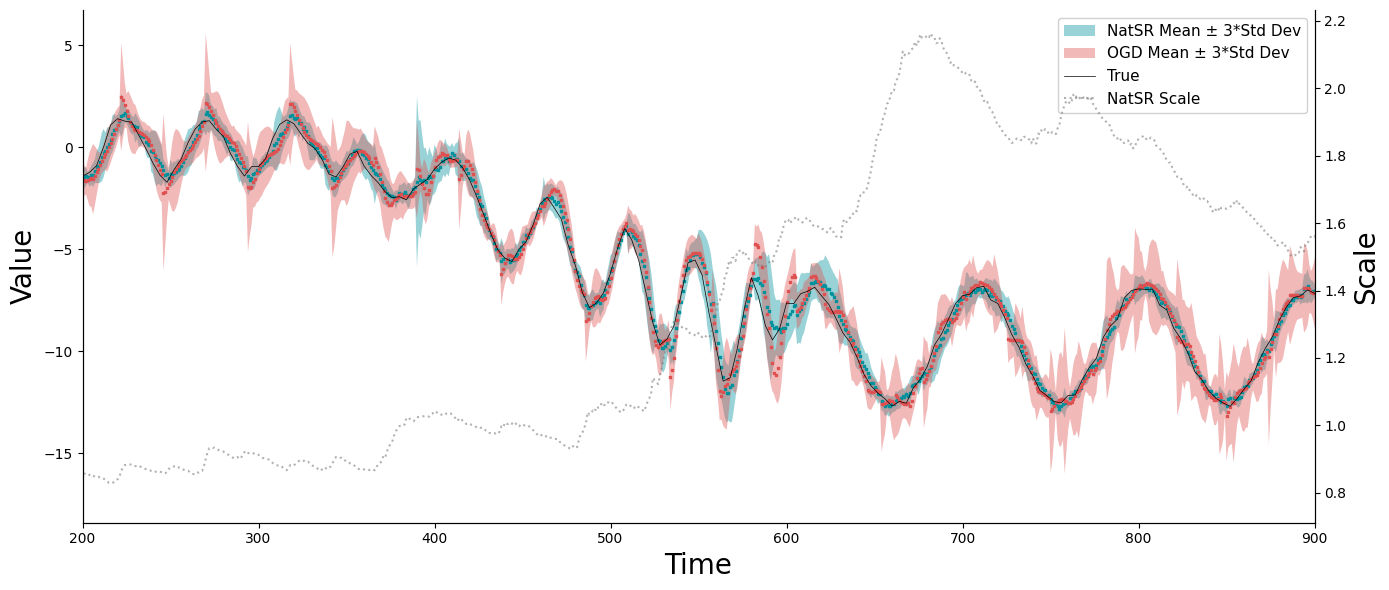

In [67]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
ax1.fill_between(mean_pred_ogd.index, mean_pred_ogd - 3*std_pred_ogd, mean_pred_ogd + 3*std_pred_ogd,
                 color=other_col, alpha=0.4, label='OGD Mean ± 3*Std Dev', linewidth=0)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=0.5)
ax1.scatter(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, s=3, marker='s')
ax1.scatter(mean_pred_ogd.index, mean_pred_ogd, color=other_col, s=3, marker='s')

ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.xlim(200, 900)
plt.tight_layout()
#plt.savefig("regime_comparison_natsr_OGD_zoomed_v2.png", dpi=300)
plt.show()

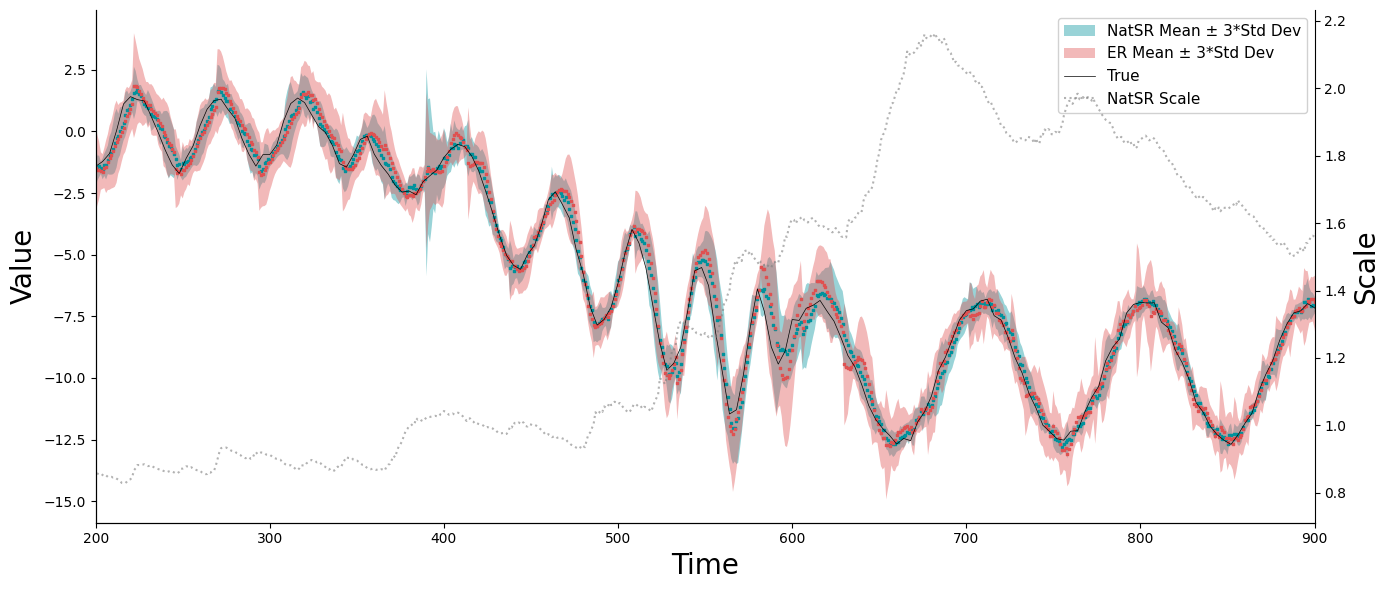

In [68]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(mean_pred_natsr.index, mean_pred_natsr - 3*std_pred_natsr, mean_pred_natsr + 3*std_pred_natsr,
                 color=natsr_col, alpha=0.4, label='NatSR Mean ± 3*Std Dev', linewidth=0)
ax1.fill_between(mean_pred_er.index, mean_pred_er - 3*std_pred_er, mean_pred_er + 3*std_pred_er,
                 color=other_col, alpha=0.4, label='ER Mean ± 3*Std Dev', linewidth=0)
ax1.plot(real_ts.index[::4], real_ts[::4], label='True', color='black', linewidth=0.5)
ax1.scatter(mean_pred_natsr.index, mean_pred_natsr, color=natsr_col, s=3, marker='s')
ax1.scatter(mean_pred_er.index, mean_pred_er, color=other_col, s=3, marker='s')

ax1.set_xlabel('Time', fontsize=20)
ax1.set_ylabel('Value', fontsize=20)

# second axis
ax2 = ax1.twinx()
ax2.plot(x, natsr_df_trial['scale'], label='NatSR Scale', color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('Scale', fontsize=20)

# Hide unwanted spines
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right',
           fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

plt.xlim(200, 900)
plt.tight_layout()
#plt.savefig("regime_comparison_natsr_ER_zoomed_v2.png", dpi=300)
plt.show()